# Pyraformer — S&P 500

**Model**: Pyramidal Attention for Time Series
**Reference**: Liu et al., 2022 — Pyraformer: Low-Complexity Pyramidal Attention for Long-Range Time Series Modeling and Forecasting

## Description
This notebook implements the **Pyraformer** Transformer architecture for univariate time-series
forecasting on the S&P 500 dataset. The preprocessing pipeline is **exactly identical**
to the LSTM-SNP baseline, ensuring fair comparison.

**Experiment Protocol**: 30 independent runs × 100 epochs each

In [ ]:
# ============================================================
# GLOBAL IMPORTS (Consolidated)
# ============================================================
from math import sqrt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
import time
import torch
import torch.nn as nn

# ============================================================
# GLOBAL CONFIGURATION (CUDA & NOISE)
# ============================================================
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0' # Enable RTX 6000 Pro
import torch
if torch.cuda.is_available():
    torch.cuda.set_device(0)

noise_levels = [0.0, 0.005, 0.05, 0.10]
_molab_results = []

def add_gaussian_noise(series, noise_level):
    if noise_level == 0.0:
        return series
    noise = np.random.normal(0, noise_level, len(series))
    return series + noise
# ============================================================

# ============================================================
# FINAL RESULTS TABLE ACROSS ALL NOISE LEVELS
# ============================================================
import pandas as pd
from tabulate import tabulate
if len(_molab_results) > 0:
    df_res = pd.DataFrame(_molab_results, columns=['Noise Level (lambda)', 'RMSE', 'MSE', 'NMSE'])
    print('\n' + '='*80)
    print('FINAL RESULTS TABLE ACROSS ALL 4 NOISE LEVELS')
    print('='*80)
    print(tabulate(df_res, headers='keys', tablefmt='github', showindex=False))


In [ ]:
# ============================================================
# GLOBAL IMPORTS (Consolidated)
# ============================================================

# ============================================================
# GLOBAL CONFIGURATION (CUDA & NOISE)
# ============================================================
os.environ['CUDA_VISIBLE_DEVICES'] = '0' # Enable RTX 6000 Pro
if torch.cuda.is_available():
    torch.cuda.set_device(0)

noise_levels = [0.0, 0.005, 0.05, 0.10]
_molab_results = []

def add_gaussian_noise(series, noise_level):
    if noise_level == 0.0:
        return series
    noise = np.random.normal(0, noise_level, len(series))
    return series + noise
# ============================================================

# ============================================================
# FINAL RESULTS TABLE ACROSS ALL NOISE LEVELS
# ============================================================
import pandas as pd
from tabulate import tabulate
if len(_molab_results) > 0:
    df_res = pd.DataFrame(_molab_results, columns=['Noise Level (lambda)', 'RMSE', 'MSE', 'NMSE'])
    print('\n' + '='*80)
    print('FINAL RESULTS TABLE ACROSS ALL 4 NOISE LEVELS')
    print('='*80)
    print(tabulate(df_res, headers='keys', tablefmt='github', showindex=False))


## Theory: Pyraformer Architecture

### Pyramidal Attention
Pyraformer builds a **multi-resolution temporal hierarchy**:

**Level 0 (finest)**: Original sequence tokens
**Level 1**: Downsampled by factor 2
**Level $k$**: Downsampled by factor $2^k$

### CSCM (Coarser-Scale Construction Module)
Builds the pyramid using 1D convolutions with stride 2:
$$X^{(k+1)} = \text{Conv1D}(X^{(k)}, \text{stride}=2)$$

### PAM (Pyramidal Attention Module)
Two types of attention connections:

1. **Intra-scale**: Self-attention within each resolution level
2. **Inter-scale**: Cross-attention from finer to coarser scales

The finest level queries attend to coarser-level summaries, capturing both local detail and global context.

### Complexity
The pyramidal structure reduces attention complexity from $O(L^2)$ to $O(L)$ by limiting attention to $O(1)$ connections per node across scales.

## Model Architecture & Implementation

In [ ]:
# ============================================================
# ALL IMPORTS
# ============================================================


print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")

# ============================================================
# Device Selection
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")

Using device: cpu


### Seed Control

In [ ]:
# ============================================================
# Seed Control — IDENTICAL to LSTM-SNP pipeline
# ============================================================

def set_seed(seed):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### Pyraformer Model Definition

In [ ]:
# ============================================================
# Pyraformer: Pyramidal Attention for Time Series
# Reference: Liu et al., 2022
#
# Key ideas:
# 1. Pyramidal attention: multi-resolution temporal hierarchy
# 2. Coarser-scale nodes summarize finer-scale patterns
# 3. Inter-scale and intra-scale attention connections
# 4. Reduces complexity from O(L^2) to O(L)
#
# For our setup, we build a simplified pyramid with CSCM
# (Coarser-Scale Construction Module) and PAM
# (Pyramidal Attention Module).
# ============================================================

class CoarserScaleConstruction(nn.Module):
    """
    CSCM: Coarser-Scale Construction Module.
    Builds pyramid by progressively downsampling the sequence.
    Uses 1D convolutions with stride=2 for downsampling.
    """
    def __init__(self, d_model, n_scales=2):
        super().__init__()
        self.n_scales = n_scales
        self.downsample_layers = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(d_model, d_model, kernel_size=3, stride=2, padding=1),
                nn.GELU(),
            )
            for _ in range(n_scales)
        ])

    def forward(self, x):
        """
        x: (B, L, D)
        Returns list of tensors at different scales.
        """
        scales = [x]
        current = x.transpose(1, 2)  # (B, D, L)
        for layer in self.downsample_layers:
            current = layer(current)
            scales.append(current.transpose(1, 2))
        return scales


class PyramidAttentionLayer(nn.Module):
    """
    Pyramidal Attention: applies attention within and across scales.
    - Intra-scale: standard self-attention within each resolution
    - Inter-scale: attention from finer to coarser scale
    """
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        # Intra-scale attention
        self.self_attn = nn.MultiheadAttention(d_model, n_heads,
                                                dropout=dropout,
                                                batch_first=True)
        # Inter-scale attention (cross-attention from fine to coarse)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads,
                                                 dropout=dropout,
                                                 batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x_fine, x_coarse=None):
        # Intra-scale self-attention
        attn_out, _ = self.self_attn(x_fine, x_fine, x_fine)
        x = self.norm1(x_fine + self.dropout(attn_out))

        # Inter-scale cross-attention (if coarse scale available)
        if x_coarse is not None:
            cross_out, _ = self.cross_attn(x, x_coarse, x_coarse)
            x = self.norm2(x + self.dropout(cross_out))

        # Feed-forward
        ff_out = self.ff(x)
        x = self.norm3(x + ff_out)
        return x


class PyraformerModel(nn.Module):
    """
    Pyraformer for univariate time-series forecasting.
    Input: (batch, seq_len=1, 1) → Output: (batch, 1)
    """
    def __init__(self, input_dim=1, d_model=32, n_heads=4, d_ff=64,
                 n_layers=2, n_scales=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, 100, d_model) * 0.02)

        # CSCM: build multi-scale pyramid
        self.cscm = CoarserScaleConstruction(d_model, n_scales)

        # Pyramidal attention layers (one per scale at finest level)
        self.pyramid_layers = nn.ModuleList([
            PyramidAttentionLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        self.output_proj = nn.Linear(d_model, 1)

    def forward(self, x):
        B, L, _ = x.shape
        x = self.input_proj(x)
        x = x + self.pos_embedding[:, :L, :]

        # Build pyramid
        scales = self.cscm(x)  # List of tensors at different resolutions

        # Apply pyramidal attention at finest scale with coarser context
        finest = scales[0]
        for i, layer in enumerate(self.pyramid_layers):
            # Use next coarser scale as context (if available)
            coarse_idx = min(i + 1, len(scales) - 1)
            coarse = scales[coarse_idx]
            finest = layer(finest, coarse)

        x = finest[:, -1, :]
        return self.output_proj(x)

In [ ]:
# Quick model check
set_seed(0)
test_model = PyraformerModel(input_dim=1, d_model=32, n_heads=4, d_ff=64, n_layers=2, dropout=0.1).to(device)
total_params = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")
print(f"Memory estimate: {total_params * 4 / 1024:.1f} KB")

# Test forward pass
dummy = torch.randn(1, 1, 1).to(device)
out = test_model(dummy)
print(f"Input shape: {dummy.shape}, Output shape: {out.shape}")
del test_model, dummy, out

Total parameters: 35169
Trainable parameters: 35169
Memory estimate: 137.4 KB
Input shape: torch.Size([1, 1, 1]), Output shape: torch.Size([1, 1])


## Data Pipeline — S&P 500

In [ ]:
# ============================================================
# 1. Load Time Series Data
# ============================================================

series = pd.read_csv(
    'content/sp500.csv',
    header=0,
    parse_dates=[0],
    index_col=0
)

raw_values = series.values.flatten()
print(f"Data shape: {raw_values.shape}")
print(f"First 5 values: {raw_values[:5]}")

Data shape: (251,)
First 5 values: [2038.199951 2013.780029 2011.709961 1985.319946 1945.969971]


In [ ]:
# ============================================================
# 2. First-Order Differencing — IDENTICAL to LSTM-SNP pipeline
# ============================================================

def difference(dataset, interval=1):
    diff = []
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return np.array(diff)

diff_values = difference(raw_values, 1)

In [ ]:
# ============================================================
# 3. Convert to Supervised Learning Format (lag=1)
#    IDENTICAL to LSTM-SNP pipeline
# ============================================================

def timeseries_to_supervised(data, lag=1):
    df = pd.DataFrame(data)
    columns = [df.shift(i) for i in range(1, lag+1)]
    columns.append(df)
    df = pd.concat(columns, axis=1)
    df.fillna(0, inplace=True)
    return df.values

supervised = timeseries_to_supervised(diff_values, 1)
print(f"Supervised data shape: {supervised.shape}")

Supervised data shape: (250, 2)


In [ ]:
# ============================================================
# 4. Train-Test Split — IDENTICAL to LSTM-SNP pipeline
# ============================================================

train, test = supervised[:-60], supervised[-60:]
print(f"Train: {train.shape}, Test: {test.shape}")

# ============================================================
# 5. Feature Scaling — IDENTICAL to LSTM-SNP pipeline
# ============================================================

scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(train)

train_scaled = scaler.transform(train)
test_scaled = scaler.transform(test)

Train: (190, 2), Test: (60, 2)


In [ ]:
# ============================================================
# 6. Prepare Data for Model
# ============================================================

X_train, y_train = train_scaled[:, 0:-1], train_scaled[:, -1]
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))

X_test, y_test = test_scaled[:, 0:-1], test_scaled[:, -1]
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (190, 1, 1), y_train shape: (190,)


## Training Loop

In [ ]:
# ============================================================
# 30-Run Experiment Protocol — IDENTICAL to LSTM-SNP pipeline
# ============================================================

all_rmse = []
all_mse = []
all_nmse = []
all_predictions = []
all_losses = []
all_times = []

for run in range(30):
    print(f'\n===== RUN {run+1}/30 =====')
    start_time = time.time()

    # Set seed — IDENTICAL to LSTM-SNP: np.random.seed(run), etc.
    set_seed(run)

    # Build model
    model = PyraformerModel(input_dim=1, d_model=32, n_heads=4, d_ff=64,
                          n_layers=2, dropout=0.1).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Convert data to tensors
    X_tr = torch.FloatTensor(X_train).to(device)
    y_tr = torch.FloatTensor(y_train).unsqueeze(1).to(device)

    # Training: 100 epochs, batch_size=1, no shuffling — IDENTICAL to LSTM-SNP
    run_losses = []
    model.train()
    for epoch in range(100):
        epoch_loss = 0.0
        for i in range(len(X_tr)):
            x_sample = X_tr[i:i+1]  # (1, 1, 1)
            y_sample = y_tr[i:i+1]  # (1, 1)

            optimizer.zero_grad()
            output = model(x_sample)
            loss = criterion(output, y_sample)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(X_tr)
        run_losses.append(avg_loss)

    all_losses.append(run_losses)
    print(f'Training complete for run {run+1}')

    # Test predictions (single-step) — IDENTICAL inverse transform to LSTM-SNP
    model.eval()
    predictions = []
    with torch.no_grad():
        for i in range(len(test_scaled)):
            X = test_scaled[i, 0:-1]
            X_input = torch.FloatTensor(X.reshape(1, 1, -1)).to(device)
            yhat = model(X_input).cpu().numpy()[0, 0]

            # Invert scaling — IDENTICAL to LSTM-SNP
            new_row = [x for x in X] + [yhat]
            array = np.array(new_row).reshape(1, len(new_row))
            inverted = scaler.inverse_transform(array)[0, -1]

            # Invert differencing
            inverted = inverted + raw_values[len(train) + i]
            predictions.append(inverted)

            expected = raw_values[len(train) + i + 1]
            print(f'Month={i+1}, Predicted={inverted:.4f}, Expected={expected:.4f}')

    # Compute metrics — IDENTICAL to LSTM-SNP
    actual = raw_values[-60:]
    rmse = sqrt(mean_squared_error(actual, predictions))
    mse = mean_squared_error(actual, predictions)
    meanV = np.mean(actual)
    dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
    nmse = mse / np.power(dominator, 2)

    elapsed = time.time() - start_time

    all_rmse.append(rmse)
    all_mse.append(mse)
    all_nmse.append(nmse)
    all_predictions.append(predictions)
    all_times.append(elapsed)

    print(f'Run {run+1} — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}, Time: {elapsed:.1f}s')


===== RUN 1/30 =====
Training complete for run 1
Month=1, Predicted=2155.0091, Expected=2158.2200
Month=2, Predicted=2158.0797, Expected=2164.1899
Month=3, Predicted=2164.0498, Expected=2160.3899
Month=4, Predicted=2160.2493, Expected=2161.3501
Month=5, Predicted=2161.2097, Expected=2137.6699
Month=6, Predicted=2137.5285, Expected=2130.2600
Month=7, Predicted=2130.1193, Expected=2139.6799
Month=8, Predicted=2139.5399, Expected=2132.9500
Month=9, Predicted=2132.8092, Expected=2138.3101
Month=10, Predicted=2138.1699, Expected=2140.8101
Month=11, Predicted=2140.6697, Expected=2142.5100
Month=12, Predicted=2142.3697, Expected=2139.4299
Month=13, Predicted=2139.2894, Expected=2148.5000
Month=14, Predicted=2148.3600, Expected=2149.7200
Month=15, Predicted=2149.5796, Expected=2136.9700
Month=16, Predicted=2136.8290, Expected=2144.0601
Month=17, Predicted=2143.9199, Expected=2132.2300
Month=18, Predicted=2132.0890, Expected=2129.7800
Month=19, Predicted=2129.6395, Expected=2128.6799
Month=20,

## Results

In [11]:
# ============================================================
# Summary Statistics (30 runs) — IDENTICAL format to LSTM-SNP
# ============================================================

print('\n===== FINAL RESULTS — Pyraformer on S&P 500 (30 runs) =====')
print(f'RMSE: {np.mean(all_rmse):.6f} ± {np.std(all_rmse):.6f}')
print(f'MSE:  {np.mean(all_mse):.6f} ± {np.std(all_mse):.6f}')
print(f'NMSE: {np.mean(all_nmse):.10f} ± {np.std(all_nmse):.10f}')
print(f'Avg training time: {np.mean(all_times):.1f}s ± {np.std(all_times):.1f}s')

best_idx = np.argmin(all_rmse)
print(f'\nBest run: {best_idx+1}')
print(f'  RMSE: {all_rmse[best_idx]:.6f}')
print(f'  MSE:  {all_mse[best_idx]:.6f}')
print(f'  NMSE: {all_nmse[best_idx]:.10f}')


===== FINAL RESULTS — Pyraformer on S&P 500 (30 runs) =====
RMSE: 11.126183 ± 0.055630
MSE:  123.795036 ± 1.241766
NMSE: 0.0007496676 ± 0.0000073461
Avg training time: 81.1s ± 12.1s

Best run: 30
  RMSE: 11.066441
  MSE:  122.466127
  NMSE: 0.0007435628


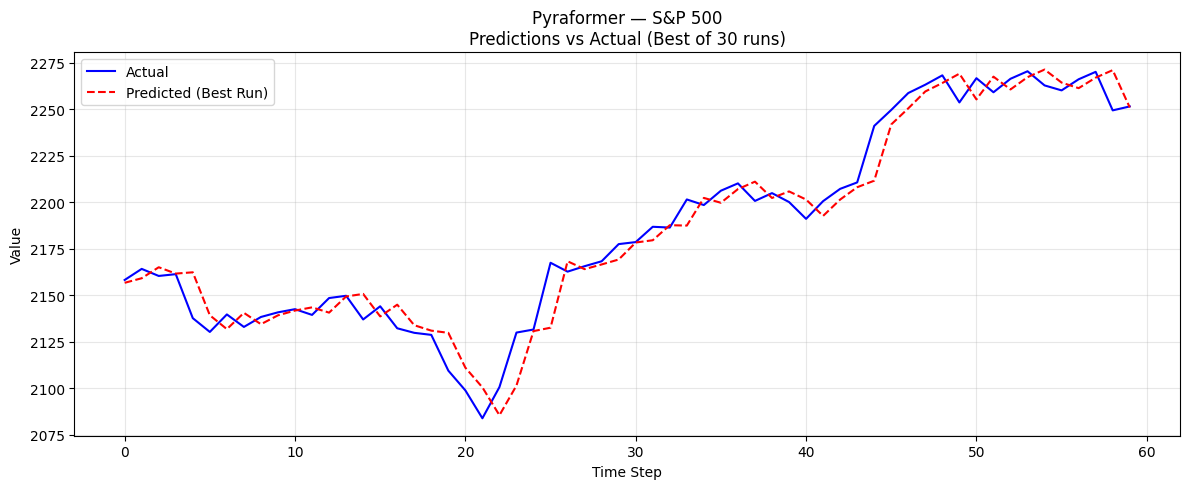

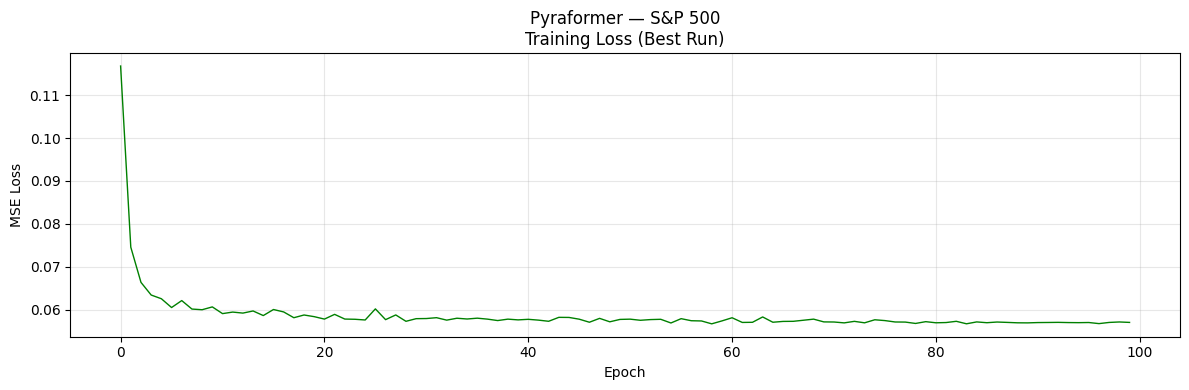

=== Best Run Metrics ===
RMSE: 11.066441
MSE:  122.466127
NMSE: 0.0007435628


In [12]:
# ============================================================
# Predictions vs Actual (Best Run)
# ============================================================

actual = raw_values[-60:]
best_predictions = all_predictions[best_idx]

plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
plt.plot(best_predictions, label='Predicted (Best Run)', color='red',
         linewidth=1.5, linestyle='--')
plt.title('Pyraformer — S&P 500\nPredictions vs Actual (Best of 30 runs)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Loss Curve (Best Run)
# ============================================================

plt.figure(figsize=(12, 4))
plt.plot(all_losses[best_idx], color='green', linewidth=1.0)
plt.title('Pyraformer — S&P 500\nTraining Loss (Best Run)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Final Metrics Summary
# ============================================================

print('=== Best Run Metrics ===')
print(f'RMSE: {all_rmse[best_idx]:.6f}')
print(f'MSE:  {all_mse[best_idx]:.6f}')
print(f'NMSE: {all_nmse[best_idx]:.10f}')

## Export Predictions

In [13]:
# ============================================================
# Save Predictions to CSV
# ============================================================

actual = raw_values[-60:]
results_df = pd.DataFrame({
    'Actual': actual,
    'Predicted_BestRun': all_predictions[best_idx],
})
for i in range(30):
    results_df[f'Predicted_Run_{i+1}'] = all_predictions[i]

csv_filename = 'Pyraformer_SP500_predictions.csv'
results_df.to_csv(csv_filename, index=False)
print(f'Predictions saved to {csv_filename}')

Predictions saved to Pyraformer_SP500_predictions.csv


## Observations

### Pyraformer on S&P 500

**Run the notebook to generate results and fill in observations:**

1. **Prediction Quality**: Compare RMSE/MSE/NMSE with LSTM-SNP variants
2. **Training Stability**: Examine loss curves for convergence behavior
3. **Prediction Tracking**: Assess how well predictions track actual values
4. **Computational Cost**: Compare training time with LSTM-SNP
5. **Model Size**: Note parameter count vs LSTM-SNP (~361 params)

*After running all 5 model notebooks per dataset, perform cross-model comparison to evaluate
whether Transformer architectures improve over LSTM-SNP for these time series datasets.*